# Учимся работе с данными - от загрузки до моделирования
Занятие: Задача классификации. Метод ближайших соседей
Будем работать в директории homework_09
Используйте ноутбук homework_09.ipynb в директории homework_09

Часть 1. EDA


Скачайте датасет по ссылке: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data
Посмотрите на базовые статистики датасета: средние, медианы и т.д.
Постройте гистограммы/распределения признаков, при этом используйте целевую переменную, чтобы сгруппировать и раскрасить гистограммы.
Постройте heatmap для матрицы корреляций, есть ли признаки, которые сильно скоррелированы? Какие это признаки?
Постройте для сильно скоррелированных признаков попарные scatterplot-ы, действительно ли наблюдается линейная зависимость?
Используя boxplots и группировку по целевой переменной, попробуйте предположить, по каким признакам наиболее удобно было бы отделить злокачественные новообразования от доброкачественных.

Также очень приветствуется ваша инициатива по визуализациям и исследовании данных :)


Часть 2. Моделирование при помощи kNN


Разбейте данные на train-test, отложив 30% выборки для тестирования.
Приведите все непрерывные переменные к одному масштабу при помощи стандартизации. Кратко поясните, почему стандартизация здесь нужна.
Постройте модель kNN «из коробки» без настройки параметров. Оцените метрики качества бинарной классификации (accuracy, precision, recall, f1_score), постройте ROC-кривую и посчитайте площадь под ней.
Теперь проведите настройку параметра числа соседей на кросс-валидации. Снова оцените результаты, стало ли лучше?

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score

# Загрузка датасета

In [3]:
# загрузка датасета
data = pd.read_csv('breast_cancer.csv',encoding='unicode_escape')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# размер датасета
data.shape

(569, 33)

In [5]:
# детальная инфо о датасете
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

# Предобработка данных

In [8]:
# удаление избыточного столбца с id и пустого столбца Unnamed: 32
data = data.drop(['id', 'Unnamed: 32'], axis = 1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [13]:
# инфа по типам данных
data.dtypes

,0
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64


# Целевая переменная и приведение к нужному типу

In [17]:
# целевая переменная - diagnosis, но у него dtype object - преобразуем (0 - ОК, 1 - NOK)
data['diagnosis'] = LabelEncoder().fit_transform(data['diagnosis'])
data['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [19]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Базовые статистики

In [18]:
# базовые статистики
data.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Гистограмма распределения

<Axes: xlabel='diagnosis', ylabel='Count'>

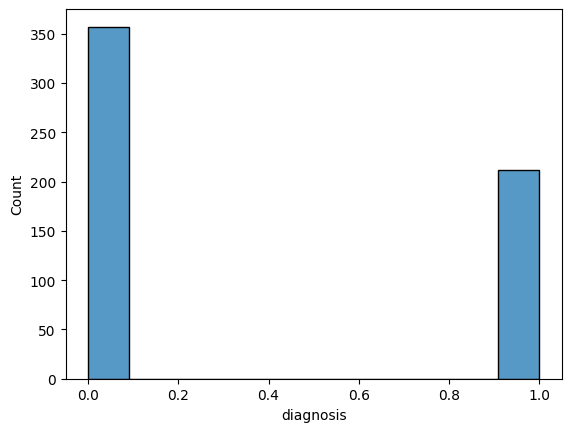

In [86]:
# распределение диагнозов по количеству
# видно, что 0 (OK) преобладает над 1 (NOK)
sns.histplot(data=data, x='diagnosis')

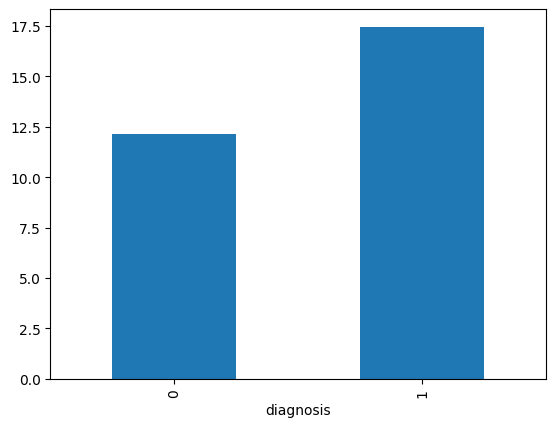

In [28]:
# зависимость diagnosis от radius_mean --> в среднем больше у diagnosis = 1 (NOK)
diagnosis_to_radius_mean = data.groupby('diagnosis')['radius_mean'].mean()
diagnosis_to_radius_mean.plot.bar();

# Корреляция

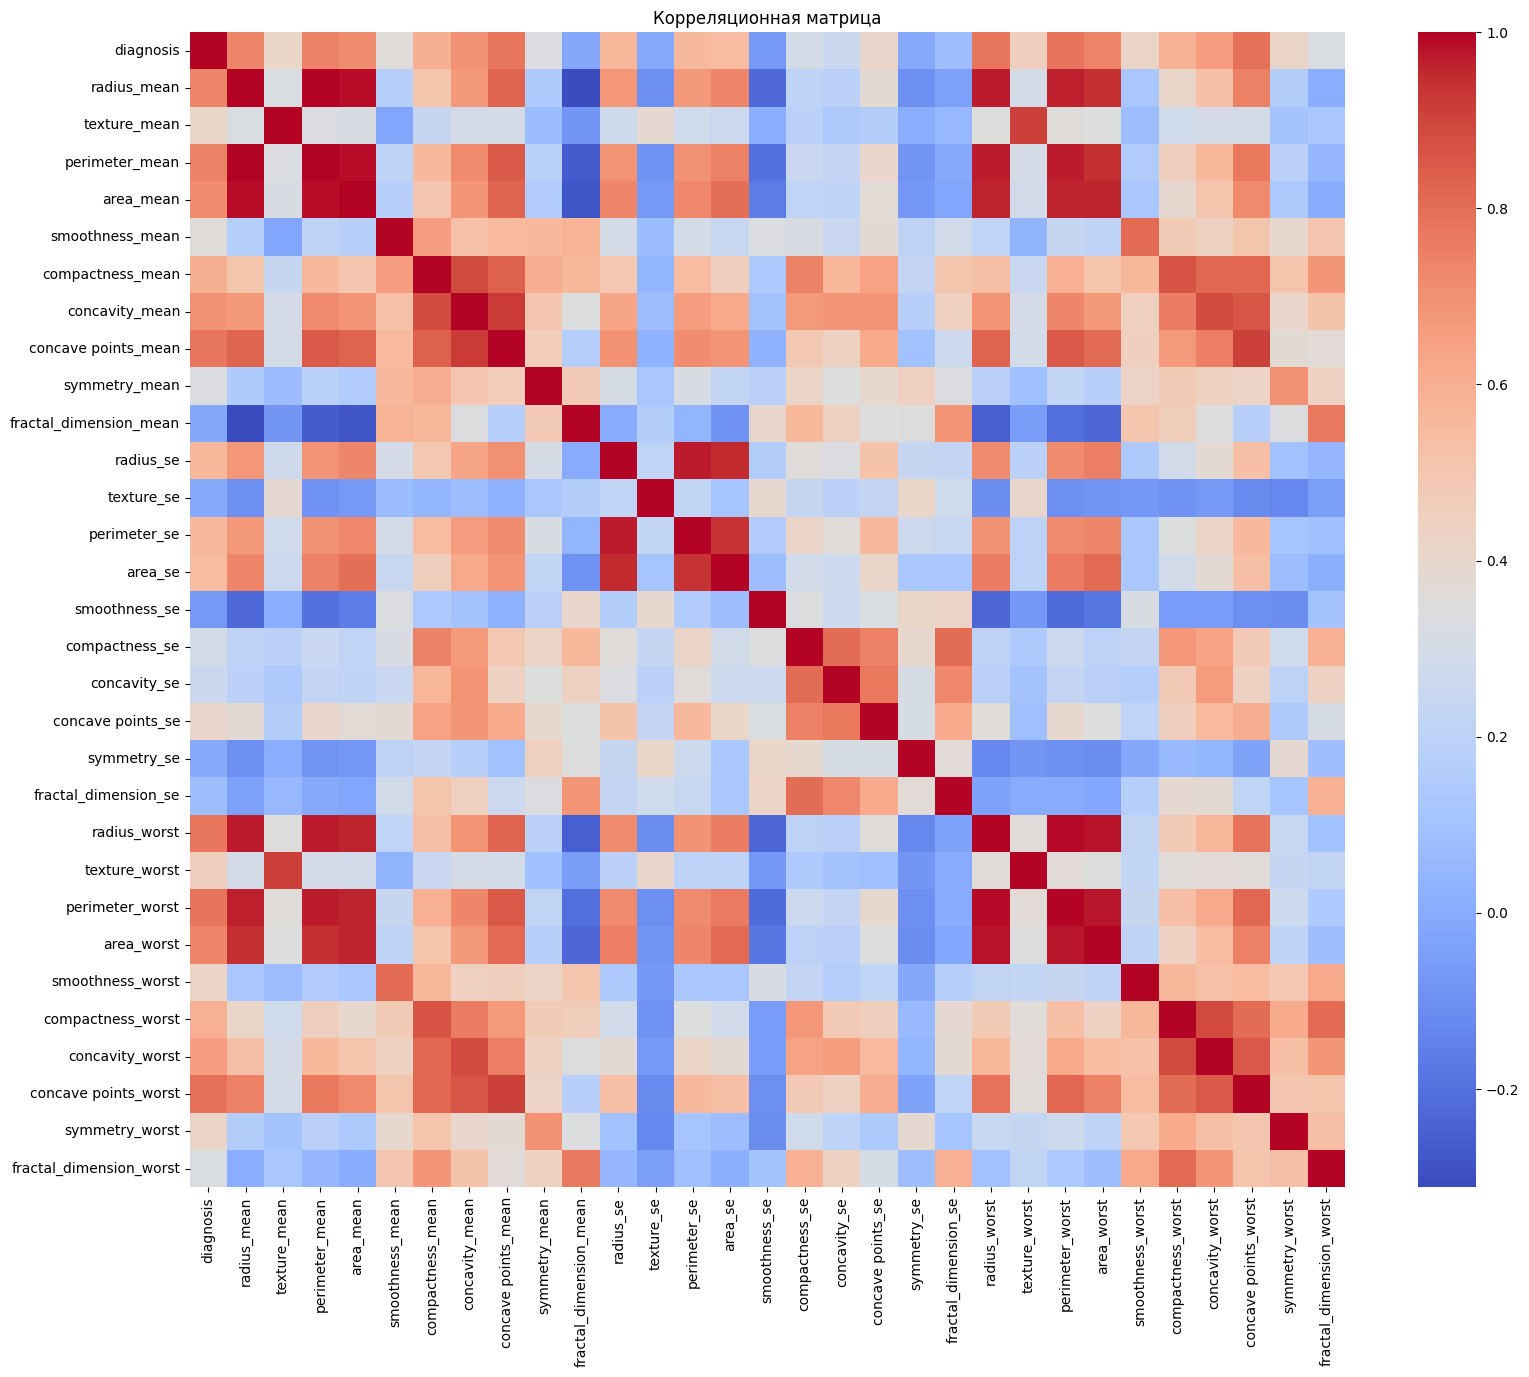

In [37]:
# heatmap корреляций
plt.figure(figsize=(19, 15))
plt.title("Корреляционная матрица")
corr = data.corr()
sns.heatmap(corr, annot=False, fmt='.2f', square=True, cmap="coolwarm");

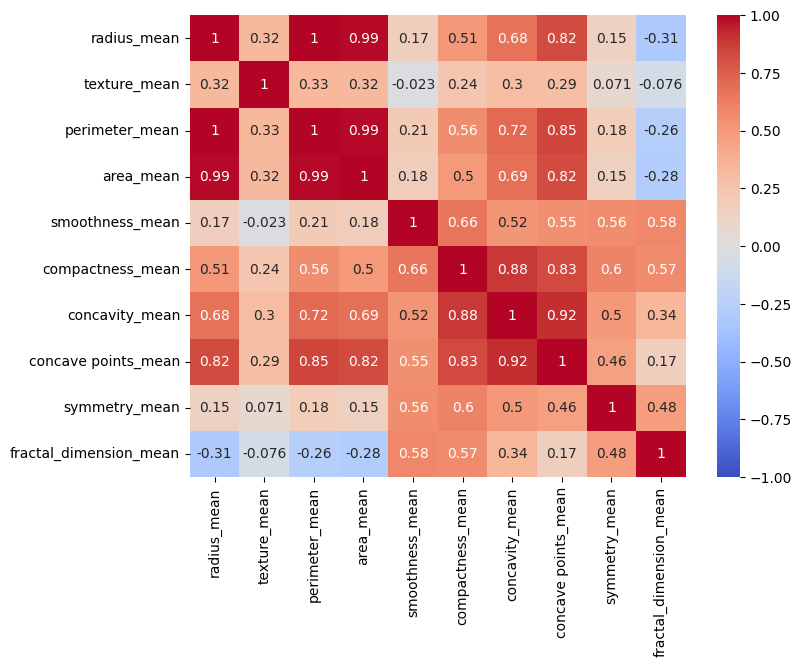

In [43]:
# видно, что корреляция между mean, se и worst - посмотрим внимательнее на них
# видна сильная корреляция между radius_mean, perimetr_mean и area_mean
# но и выделяются concavity_mean, concave points_mean и compactness_mean
data_corr = data.iloc[:, 1:11]
plt.subplots(figsize = (8, 6))
sns.heatmap(data_corr.corr(), cmap = sns.color_palette('coolwarm', 10000), vmin = -1, center =0, annot = True)
plt.show()

# Скаттерплоты для коррелирующих признаков

<Axes: xlabel='radius_mean', ylabel='perimeter_mean'>

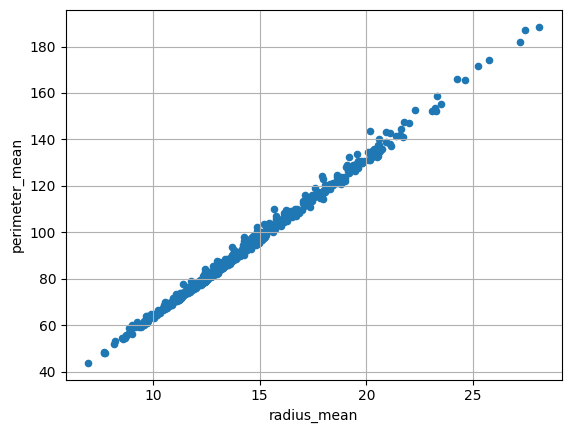

In [50]:
# скаттерплоты для сильноскоррелированных признаков
# Прослеживается линейная зависимость perimeter и radius
data.plot.scatter(x = 'radius_mean', y = 'perimeter_mean', grid = True)


<Axes: xlabel='radius_mean', ylabel='area_mean'>

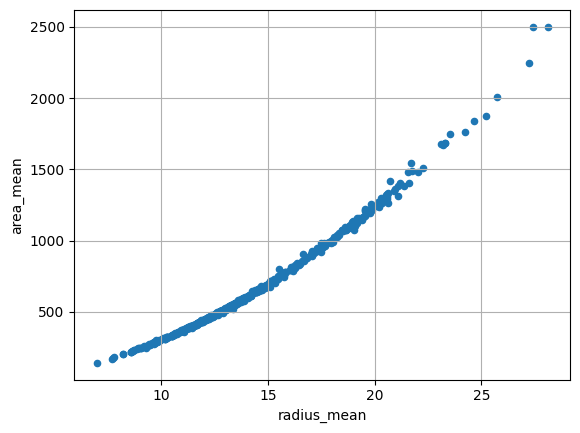

In [45]:
data.plot.scatter(x = 'radius_mean', y = 'area_mean', grid = True)

<Axes: xlabel='perimeter_mean', ylabel='area_mean'>

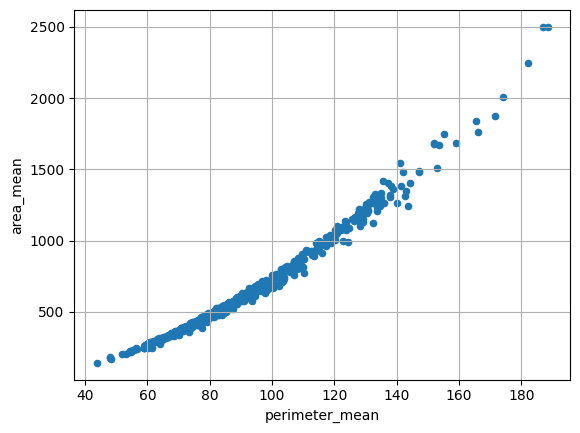

In [46]:
data.plot.scatter(x = 'perimeter_mean', y = 'area_mean', grid = True)

<Axes: xlabel='radius_mean', ylabel='concave points_mean'>

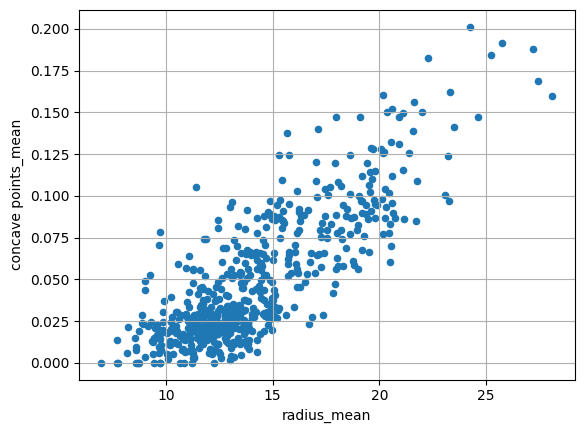

In [47]:
data.plot.scatter(x = 'radius_mean', y = 'concave points_mean', grid = True)

<Axes: xlabel='concavity_mean', ylabel='concave points_mean'>

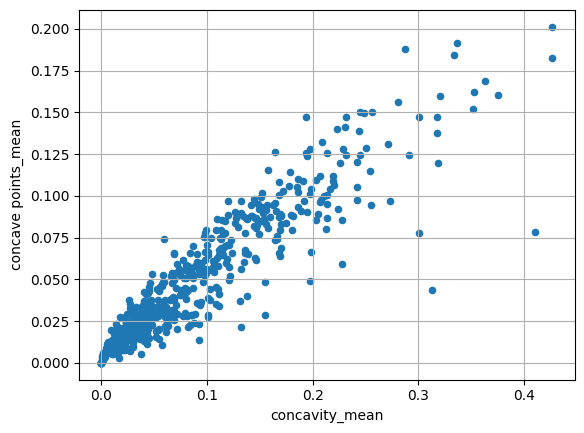

In [48]:
data.plot.scatter(x = 'concavity_mean', y = 'concave points_mean', grid = True)

<Axes: xlabel='compactness_mean', ylabel='concave points_mean'>

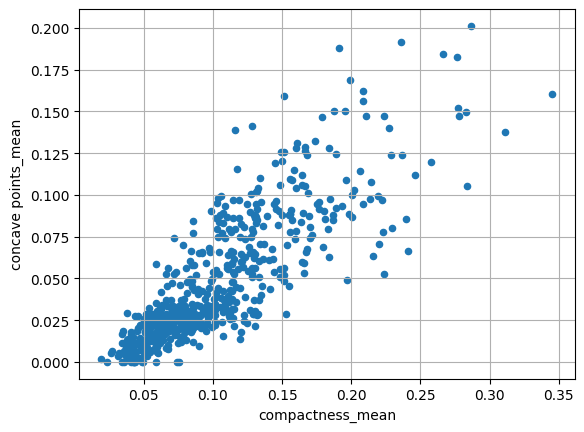

In [49]:
data.plot.scatter(x = 'compactness_mean', y = 'concave points_mean', grid = True)

# Боксплоты

<Axes: xlabel='diagnosis', ylabel='radius_mean'>

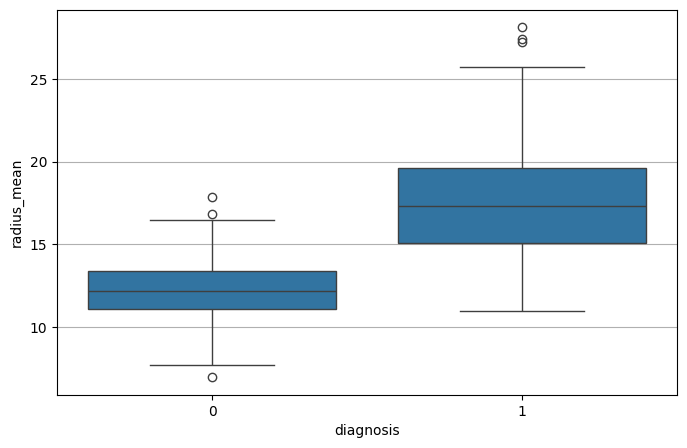

In [55]:
# boxplots с целевой переменной diagnosis
# выглядит, что удобно работать с radius_mean, texture_mean, smoothness_mean и compactness_mean
plt.figure(figsize = (8,5))
plt.grid(visible = True)
sns.boxplot(data = data, x = 'diagnosis', y = 'radius_mean')

<Axes: xlabel='diagnosis', ylabel='texture_mean'>

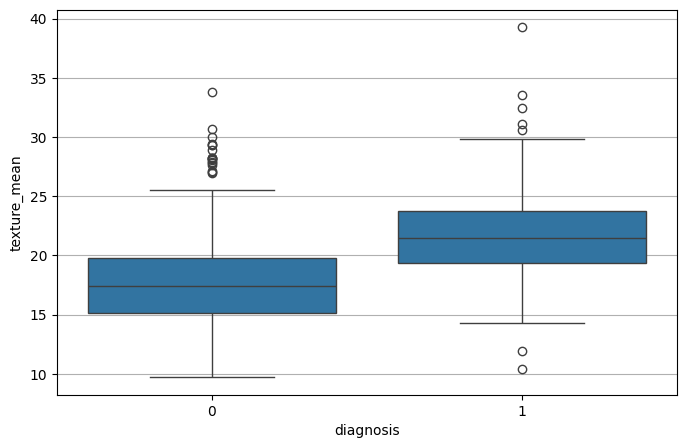

In [56]:
plt.figure(figsize = (8,5))
plt.grid(visible = True)
sns.boxplot(data = data, x = 'diagnosis', y = 'texture_mean')

<Axes: xlabel='diagnosis', ylabel='smoothness_mean'>

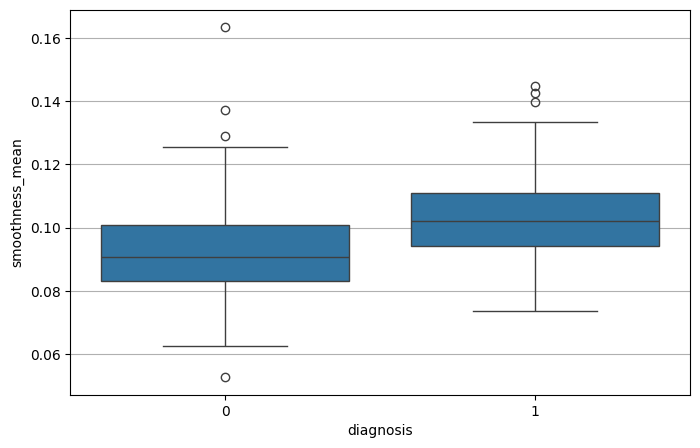

In [57]:
plt.figure(figsize = (8,5))
plt.grid(visible = True)
sns.boxplot(data = data, x = 'diagnosis', y = 'smoothness_mean')

<Axes: xlabel='diagnosis', ylabel='compactness_mean'>

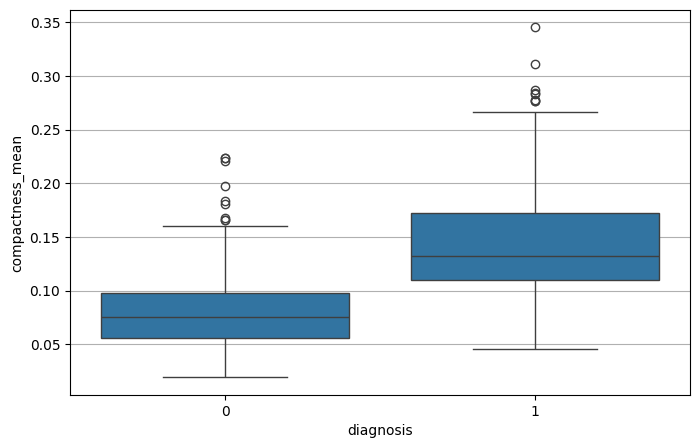

In [58]:
plt.figure(figsize = (8,5))
plt.grid(visible = True)
sns.boxplot(data = data, x = 'diagnosis', y = 'compactness_mean')

<Axes: xlabel='diagnosis', ylabel='symmetry_mean'>

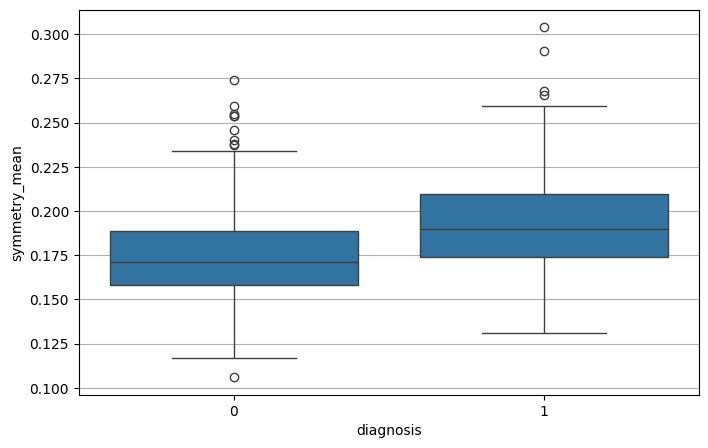

In [59]:
plt.figure(figsize = (8,5))
plt.grid(visible = True)
sns.boxplot(data = data, x = 'diagnosis', y = 'symmetry_mean')

<Axes: xlabel='diagnosis', ylabel='fractal_dimension_mean'>

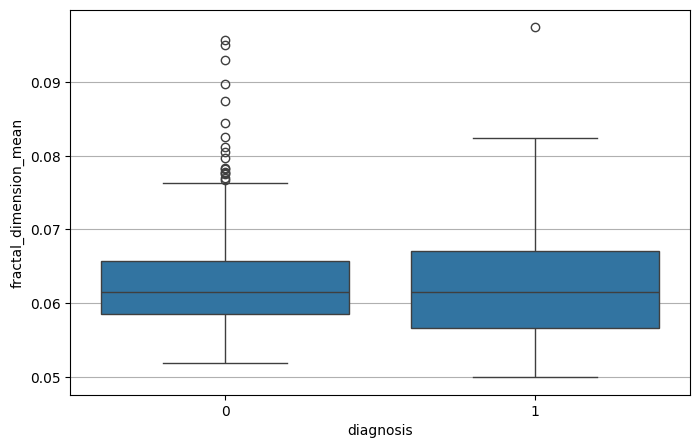

In [60]:
plt.figure(figsize = (8,5))
plt.grid(visible = True)
sns.boxplot(data = data, x = 'diagnosis', y = 'fractal_dimension_mean')

# Разбивка данных

In [64]:
# Разбивка данных (30% тестовый набор)
X = data.drop(['diagnosis'], axis=1)
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

# Шкалирование

In [65]:
# шкалирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# kNN

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       108
           1       0.95      0.94      0.94        63

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



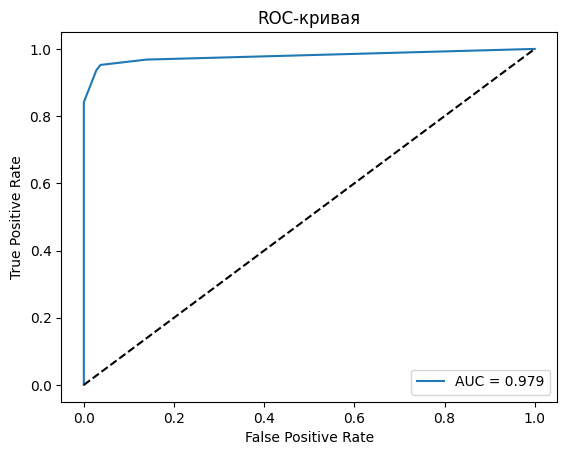

In [71]:
# kNN
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

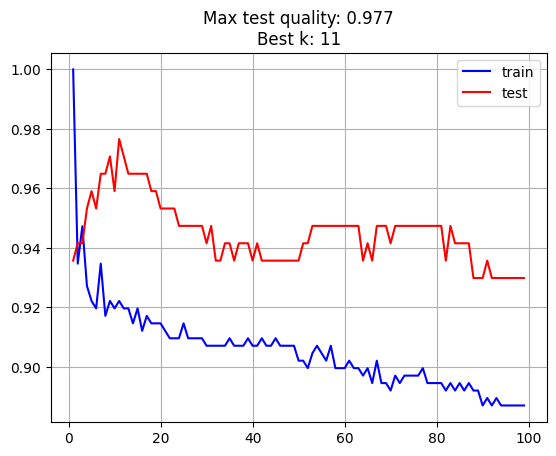

In [81]:
# Подбор количества соседей
neighbors = range(1, 100)
accuracy_train = []
accuracy_test = []
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy_train.append(accuracy_score(knn.predict(X_train), y_train))
    accuracy_test.append(accuracy_score(knn.predict(X_test), y_test))

plt.plot(neighbors, accuracy_train, color='blue', label='train')
plt.plot(neighbors, accuracy_test, color='red', label='test')
plt.title("Max test quality: {:.3f}\nBest k: {}".format(max(accuracy_test), np.argmax(accuracy_test)+1))
plt.legend()
plt.grid(visible = True)
plt.show()

# Кросс-валидация

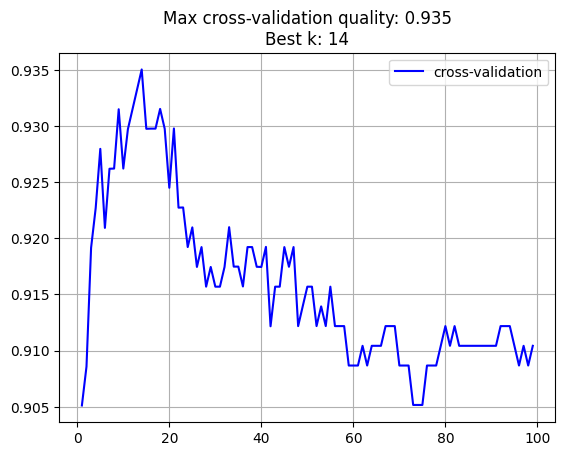

In [82]:
# Кросс-валидация
data_cross_val_accuracy = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    data_cross_val_accuracy.append(scores.mean())

plt.plot(neighbors, data_cross_val_accuracy, color='blue', label='cross-validation')
plt.title("Max cross-validation quality: {:.3f}\nBest k: {}".format(max(data_cross_val_accuracy), np.argmax(data_cross_val_accuracy)+1))
plt.legend()
plt.grid(visible = True)
plt.show()

# Выводы
Высокая точность подтверждается Precision, Recall и f1-score на уровне 0.96.

Оптимальные параметры:
*   при k=11 точность 0.977
*   при k=14 точность 0.935


